# BigMart Sales — LightGBM Standalone Model
## Pipeline: Preprocessing → Feature Engineering → Target Encoding → Grocery Split → Optuna → LightGBM

**Purpose:** Baseline individual model score for LightGBM before ensembling.  
**Metric:** RMSE on raw sales (model trained on log1p target)  
**Architecture:** Full production pipeline — same as `04_Full_Solution.ipynb` but single model.


## 0 · Install Dependencies

## 1 · Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base            import BaseEstimator, TransformerMixin
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import BayesianRidge
from sklearn.model_selection import KFold
from sklearn.metrics         import mean_squared_error
from sklearn.inspection      import permutation_importance

TRAIN_PATH = 'data/train_v9rqX0R.csv'
TEST_PATH  = 'data/test_AbJTz2l.csv'
SUB_PATH   = 'data/sample_submission_8RXa3c6.csv'
OUT_PATH   = 'outputs/submission_bigmart_lgb.csv'

N_FOLDS          = 5
SEED             = 42
N_TRIALS_MAIN    = 100
N_TRIALS_GROCERY = 60
MODEL_TYPE       = 'lgb'

os.makedirs('outputs', exist_ok=True)
np.random.seed(SEED)
print(f'Model : LightGBM')
print(f'Optuna: {optuna.__version__}')


Model : LightGBM
Optuna: 4.8.0


## 2 · DataLoader

In [2]:
class DataLoader:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path  = test_path

    def load(self):
        train = pd.read_csv(self.train_path)
        test  = pd.read_csv(self.test_path)
        train['_split'] = 'train'
        test['_split']  = 'test'
        print(f'[DataLoader] train={train.shape}  test={test.shape}')
        return train, test

loader = DataLoader(TRAIN_PATH, TEST_PATH)
train_raw, test_raw = loader.load()


[DataLoader] train=(8523, 13)  test=(5681, 12)


## 3 · Preprocessor

In [3]:
class Preprocessor(BaseEstimator, TransformerMixin):
    _FAT_MAP = {'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'}

    def __init__(self):
        self._item_weight_map = {}
        self._global_weight   = 0.0
        self._item_vis_map    = {}
        self._outlet_size_map = {}

    def fit(self, df, y=None):
        tmp = df.copy()
        tmp['Item_Fat_Content'] = tmp['Item_Fat_Content'].replace(self._FAT_MAP)
        self._item_weight_map = tmp.groupby('Item_Identifier')['Item_Weight'].mean().to_dict()
        self._global_weight   = tmp['Item_Weight'].mean()
        vis = tmp.copy()
        vis.loc[vis['Item_Visibility']==0,'Item_Visibility'] = np.nan
        self._item_vis_map = vis.groupby('Item_Identifier')['Item_Visibility'].mean().to_dict()
        self._outlet_size_map = (
            tmp.dropna(subset=['Outlet_Size'])
               .groupby('Outlet_Type')['Outlet_Size']
               .agg(lambda x: x.mode().iloc[0]).to_dict()
        )
        return self

    def transform(self, df):
        df = df.copy()
        df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(self._FAT_MAP)
        df['Item_Weight'] = df.apply(
            lambda r: self._item_weight_map.get(r['Item_Identifier'], self._global_weight)
                      if pd.isna(r['Item_Weight']) else r['Item_Weight'], axis=1)
        df['Item_Visibility'] = df.apply(
            lambda r: self._item_vis_map.get(r['Item_Identifier'], r['Item_Visibility'])
                      if r['Item_Visibility']==0 else r['Item_Visibility'], axis=1)
        df['Outlet_Size'] = df.apply(
            lambda r: self._outlet_size_map.get(r['Outlet_Type'],'Small')
                      if pd.isna(r['Outlet_Size']) else r['Outlet_Size'], axis=1)
        return df

combined_raw = pd.concat([train_raw, test_raw], ignore_index=True, sort=False)
prep = Preprocessor()
prep.fit(combined_raw)
train_clean = prep.transform(train_raw)
test_clean  = prep.transform(test_raw)
combined    = pd.concat([train_clean, test_clean], ignore_index=True, sort=False)
print('Missing post-preprocessing:', combined[['Item_Weight','Item_Visibility','Outlet_Size']].isnull().sum().to_dict())


Missing post-preprocessing: {'Item_Weight': 0, 'Item_Visibility': 0, 'Outlet_Size': 0}


## 4 · FeatureEngineer

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    _ORDINAL_SIZE     = {'Small':0,'Medium':1,'High':2}
    _ORDINAL_LOCATION = {'Tier 3':0,'Tier 2':1,'Tier 1':2}
    _OUTLET_TYPE_ORD  = {'Grocery Store':0,'Supermarket Type1':1,
                         'Supermarket Type2':2,'Supermarket Type3':3}
    _DROP = ['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year','_split']

    def __init__(self):
        self._label_encoders = {}
        self._item_vis_mean  = {}
        self._mrp_type_mean  = {}

    def fit(self, df, y=None):
        tmp = self._static(df.copy())
        self._item_vis_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean().to_dict()
        self._mrp_type_mean = df.groupby('Item_Type')['Item_MRP'].mean().to_dict()
        for col in tmp.select_dtypes('object').columns:
            if col in ['Item_Outlet_Sales','Item_Identifier','Outlet_Identifier','_split']:
                continue
            le = LabelEncoder()
            le.fit(tmp[col].astype(str))
            self._label_encoders[col] = le
        return self

    def transform(self, df):
        df = df.copy()
        df = self._static(df)
        df['Item_Visibility_MeanRatio'] = df.apply(
            lambda r: r['Item_Visibility'] /
                      self._item_vis_mean.get(r['Item_Identifier'], r['Item_Visibility']+1e-6), axis=1)
        df['MRP_Per_Category'] = df.apply(
            lambda r: r['Item_MRP'] / self._mrp_type_mean.get(r['Item_Type'], r['Item_MRP']+1e-6), axis=1)
        df['Item_Cat_x_Outlet'] = df['Item_Category'].astype(str)+'_'+df['Outlet_Type'].astype(str)
        df.drop(columns=[c for c in self._DROP if c in df.columns], inplace=True)
        for col in df.select_dtypes('object').columns:
            if col=='Item_Outlet_Sales': continue
            le = self._label_encoders.get(col)
            if le: df[col] = le.transform(df[col].astype(str))
            else:  df[col] = LabelEncoder().fit_transform(df[col].astype(str))
        return df

    @classmethod
    def _static(cls, df):
        df['Outlet_Age']           = 2013 - df['Outlet_Establishment_Year']
        df['Item_Category']        = df['Item_Identifier'].str[:2]
        df.loc[df['Item_Category']=='NC','Item_Fat_Content'] = 'Non-Edible'
        df['Log_Item_Visibility']  = np.log1p(df['Item_Visibility'])
        df['MRP_Bin']              = pd.qcut(df['Item_MRP'], q=16, labels=False, duplicates='drop')
        df['MRP_x_OutletType']     = df['Item_MRP'] * df['Outlet_Type'].map(cls._OUTLET_TYPE_ORD).fillna(0)
        df['Is_Grocery']           = (df['Outlet_Type']=='Grocery Store').astype(int)
        df['Outlet_Size']          = df['Outlet_Size'].map(cls._ORDINAL_SIZE)
        df['Outlet_Location_Type'] = df['Outlet_Location_Type'].map(cls._ORDINAL_LOCATION)
        return df

fe = FeatureEngineer()
fe.fit(combined)
train_fe = fe.transform(train_clean)
test_fe  = fe.transform(test_clean)
print(f'Features: {[c for c in train_fe.columns if c != "Item_Outlet_Sales"]}')


Features: ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Age', 'Item_Category', 'Log_Item_Visibility', 'MRP_Bin', 'MRP_x_OutletType', 'Is_Grocery', 'Item_Visibility_MeanRatio', 'MRP_Per_Category', 'Item_Cat_x_Outlet']


## 5 · KFoldTargetEncoder

In [5]:
class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    ENCODE_COLS = ['Item_Identifier','Outlet_Identifier',
                   'Item_Type','Item_Category','Item_Cat_x_Outlet']

    def __init__(self, n_folds=5, alpha=10.0, seed=42):
        self.n_folds = n_folds
        self.alpha   = alpha
        self.seed    = seed
        self._global_mean = 0.0
        self._encode_maps = {}

    def fit(self, train_df, target_series):
        self._global_mean = target_series.mean()
        for col in self.ENCODE_COLS:
            if col not in train_df.columns: continue
            stats = target_series.groupby(train_df[col]).agg(['sum','count'])
            self._encode_maps[col] = (
                (stats['sum'] + self.alpha * self._global_mean) /
                (stats['count'] + self.alpha)
            ).to_dict()
        return self

    def transform_train(self, train_df, target_series):
        df = train_df.copy()
        kf = KFold(self.n_folds, shuffle=True, random_state=self.seed)
        for col in self.ENCODE_COLS:
            if col not in df.columns: continue
            enc = np.full(len(df), self._global_mean)
            for tr, va in kf.split(df):
                stats = target_series.iloc[tr].groupby(df[col].iloc[tr]).agg(['sum','count'])
                sm    = ((stats['sum'] + self.alpha * self._global_mean) /
                         (stats['count'] + self.alpha))
                enc[va] = df[col].iloc[va].map(sm).fillna(self._global_mean).values
            df[f'TE_{col}'] = enc
        return df

    def transform_test(self, test_df):
        df = test_df.copy()
        for col in self.ENCODE_COLS:
            if col not in df.columns: continue
            df[f'TE_{col}'] = df[col].map(self._encode_maps.get(col,{})).fillna(self._global_mean)
        return df

def rebuild_with_ids(clean_df, fe):
    df = FeatureEngineer._static(clean_df.copy())
    df['Item_Visibility_MeanRatio'] = df.apply(
        lambda r: r['Item_Visibility'] /
                  fe._item_vis_mean.get(r['Item_Identifier'], r['Item_Visibility']+1e-6), axis=1)
    df['MRP_Per_Category'] = df.apply(
        lambda r: r['Item_MRP'] / fe._mrp_type_mean.get(r['Item_Type'], r['Item_MRP']+1e-6), axis=1)
    df['Item_Cat_x_Outlet'] = df['Item_Category'].astype(str)+'_'+df['Outlet_Type'].astype(str)
    return df

TARGET    = 'Item_Outlet_Sales'
train_ids = rebuild_with_ids(train_clean, fe)
test_ids  = rebuild_with_ids(test_clean,  fe)
log_y     = np.log1p(train_ids[TARGET])

te = KFoldTargetEncoder(n_folds=N_FOLDS, alpha=10.0, seed=SEED)
te.fit(train_ids, log_y)
train_te = te.transform_train(train_ids, log_y)
test_te  = te.transform_test(test_ids)

DROP = ['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year','_split']
TE_COLS = KFoldTargetEncoder.ENCODE_COLS

def finalize(df, fe, drop, te_cols):
    df = df.copy()
    df.drop(columns=[c for c in drop+te_cols if c in df.columns], inplace=True)
    for col in df.select_dtypes('object').columns:
        if col==TARGET: continue
        le = fe._label_encoders.get(col)
        if le: df[col] = le.transform(df[col].astype(str))
        else:  df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df

train_final = finalize(train_te, fe, DROP, TE_COLS)
test_final  = finalize(test_te,  fe, DROP, TE_COLS)
FEATURES    = [c for c in train_final.columns if c != TARGET]
print(f'Final features ({len(FEATURES)}): {FEATURES}')


Final features (19): ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Age', 'Log_Item_Visibility', 'MRP_Bin', 'MRP_x_OutletType', 'Is_Grocery', 'Item_Visibility_MeanRatio', 'MRP_Per_Category', 'TE_Item_Identifier', 'TE_Outlet_Identifier', 'TE_Item_Type', 'TE_Item_Category', 'TE_Item_Cat_x_Outlet']


## 6 · GrocerySplitter

In [6]:
test_grocery_mask    = test_final['Is_Grocery'] == 1
X_test_grocery       = test_final[FEATURES][test_grocery_mask].values
X_test_supermarket   = test_final[FEATURES][~test_grocery_mask].values

sup_mask  = train_final['Is_Grocery'] == 0
groc_mask = train_final['Is_Grocery'] == 1

X_sup,  y_sup  = train_final[FEATURES][sup_mask].values,  np.log1p(train_final[TARGET][sup_mask].values)
X_groc, y_groc = train_final[FEATURES][groc_mask].values, np.log1p(train_final[TARGET][groc_mask].values)

print(f'Supermarket train: {len(y_sup):,}  |  Grocery train: {len(y_groc):,}')
print(f'Supermarket test : {X_test_supermarket.shape[0]:,}  |  Grocery test : {X_test_grocery.shape[0]:,}')


Supermarket train: 7,440  |  Grocery train: 1,083
Supermarket test : 4,959  |  Grocery test : 722


## 7 · OptunaTuner (LightGBM)

In [7]:
class OptunaTuner:
    """
    Optuna TPE tuner for LightGBM.
    Minimises 5-fold OOF RMSE on log-target.
    MedianPruner kills poor trials early.
    """
    def __init__(self, n_trials=100, n_folds=5, seed=42):
        self.n_trials = n_trials
        self.n_folds  = n_folds
        self.seed     = seed
        self.study    = None
        self.best_params_: dict = {}

    def _suggest(self, trial):
        return {
            'n_estimators'      : trial.suggest_int  ('n_estimators',    300, 2000),
            'max_depth'         : trial.suggest_int  ('max_depth',          3,   12),
            'learning_rate'     : trial.suggest_float('learning_rate',  0.005,  0.3, log=True),
            'num_leaves'        : trial.suggest_int  ('num_leaves',        20,  300),
            'subsample'         : trial.suggest_float('subsample',        0.5,  1.0),
            'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4,  1.0),
            'min_child_samples' : trial.suggest_int  ('min_child_samples',  5,  100),
            'reg_alpha'         : trial.suggest_float('reg_alpha',       1e-8, 10.0, log=True),
            'reg_lambda'        : trial.suggest_float('reg_lambda',      1e-8, 10.0, log=True),
            'min_split_gain'    : trial.suggest_float('min_split_gain',   0.0,  1.0),
            'random_state':self.seed, 'n_jobs':-1, 'verbosity':-1,
        }

    def _make_model(self, params):
        return lgb.LGBMRegressor(**params)

    def _objective(self, trial, X, y):
        params = self._suggest(trial)
        kf, oof = KFold(self.n_folds, shuffle=True, random_state=self.seed), np.zeros(len(y))
        for step, (tr, va) in enumerate(kf.split(X)):
            m = self._make_model(params)
            m.fit(X[tr], y[tr])
            oof[va] = m.predict(X[va])
            trial.report(np.sqrt(mean_squared_error(y[va], oof[va])), step=step)
            if trial.should_prune(): raise optuna.exceptions.TrialPruned()
        return np.sqrt(mean_squared_error(y, oof))

    def tune(self, X, y, study_name='') -> dict:
        self.study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(seed=self.seed),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
            study_name=study_name
        )
        self.study.optimize(lambda t: self._objective(t, X, y),
                            n_trials=self.n_trials, show_progress_bar=True)
        self.best_params_ = self.study.best_params
        self.best_params_.update(self._fixed_params())
        print(f'[{study_name}] best OOF RMSE (log): {self.study.best_value:.5f}'
              f'  → raw: {np.expm1(self.study.best_value):,.1f}')
        return self.best_params_

    def _fixed_params(self):
        if MODEL_TYPE == 'xgb':
            return {'tree_method':'hist','random_state':self.seed,'n_jobs':-1,'verbosity':0}
        elif MODEL_TYPE == 'lgb':
            return {'random_state':self.seed,'n_jobs':-1,'verbosity':-1}
        elif MODEL_TYPE == 'cat':
            return {'random_seed':self.seed,'verbose':0,'allow_writing_files':False}
        return {}


## 8 · Run Optuna (Supermarket + Grocery)

In [8]:
print('Tuning LightGBM — Supermarket split ...')
tuner_sup  = OptunaTuner(n_trials=N_TRIALS_MAIN,    seed=SEED)
params_sup = tuner_sup.tune(X_sup, y_sup, 'lgb_supermarket')

print()
print('Tuning LightGBM — Grocery split ...')
tuner_groc  = OptunaTuner(n_trials=N_TRIALS_GROCERY, seed=SEED)
params_groc = tuner_groc.tune(X_groc, y_groc, 'lgb_grocery')


Tuning LightGBM — Supermarket split ...


Best trial: 91. Best value: 0.51138: 100%|██████████| 100/100 [04:37<00:00,  2.78s/it]


[lgb_supermarket] best OOF RMSE (log): 0.51138  → raw: 0.7

Tuning LightGBM — Grocery split ...


Best trial: 49. Best value: 0.564022: 100%|██████████| 60/60 [00:58<00:00,  1.02it/s]

[lgb_grocery] best OOF RMSE (log): 0.56402  → raw: 0.8


## 9 · Optuna Diagnostics

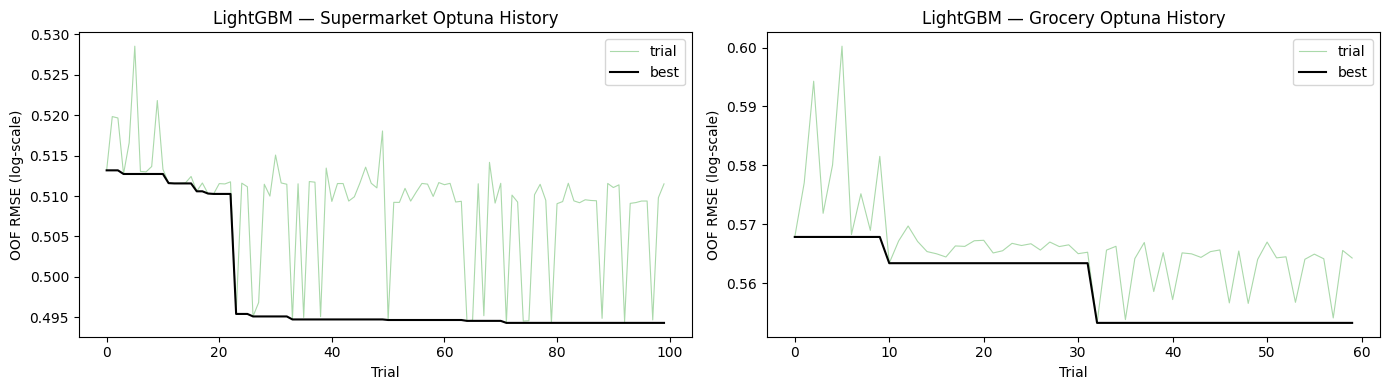

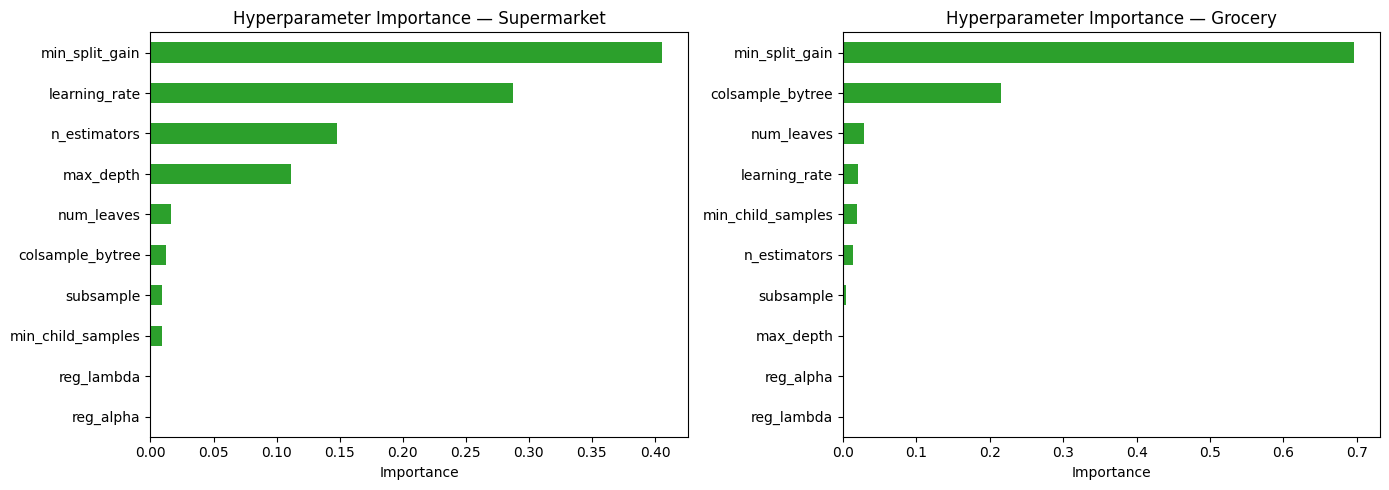

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (study, name) in zip(axes, [(tuner_sup.study, 'Supermarket'),
                                     (tuner_groc.study, 'Grocery')]):
    vals = [t.value for t in study.trials if t.value is not None]
    ax.plot(vals, alpha=0.4, color='#2ca02c', lw=0.8, label='trial')
    ax.plot(pd.Series(vals).cummin(), color='black', lw=1.5, label='best')
    ax.set_title(f'LightGBM — {name} Optuna History')
    ax.set_xlabel('Trial'); ax.set_ylabel('OOF RMSE (log-scale)')
    ax.legend()
plt.tight_layout()
plt.show()

# Hyperparameter importance
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (study, name) in zip(axes, [(tuner_sup.study, 'Supermarket'),
                                         (tuner_groc.study, 'Grocery')]):
        imp = optuna.importance.get_param_importances(study)
        pd.Series(imp).sort_values().plot(kind='barh', ax=ax, color='#2ca02c')
        ax.set_title(f'Hyperparameter Importance — {name}')
        ax.set_xlabel('Importance')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Param importance unavailable: {e}')


## 10 · LightGBMTrainer — CV + Full Fit

In [10]:
class SingleModelTrainer:
    """
    Trains LightGBM with tuned params.
    cv_evaluate() : 5-fold OOF RMSE on raw sales scale
    fit()         : full training data
    predict()     : expm1 of log-predictions
    """
    def __init__(self, params: dict, n_folds=5, seed=42):
        self.params  = params
        self.n_folds = n_folds
        self.seed    = seed
        self.model_  = None
        self._oof_preds = None

    def _make(self):
        return lgb.LGBMRegressor(**self.params)

    def cv_evaluate(self, X, y) -> dict:
        kf  = KFold(self.n_folds, shuffle=True, random_state=self.seed)
        oof = np.zeros(len(y))
        fold_rmses = []
        for fold, (tr, va) in enumerate(kf.split(X), 1):
            m = self._make()
            m.fit(X[tr], y[tr])
            oof[va] = m.predict(X[va])
            rmse = np.sqrt(mean_squared_error(np.expm1(y[va]), np.expm1(oof[va])))
            fold_rmses.append(rmse)
            print(f'  Fold {fold}: RMSE = {rmse:,.2f}')
        oof_rmse = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(oof)))
        print(f'  OOF  RMSE = {oof_rmse:,.2f}')
        print(f'  Mean±Std  = {np.mean(fold_rmses):,.2f} ± {np.std(fold_rmses):.2f}')
        self._oof_preds = np.expm1(oof)
        return {'oof_rmse': oof_rmse, 'fold_rmses': fold_rmses,
                'oof_preds': self._oof_preds}

    def fit(self, X, y):
        self.model_ = self._make()
        self.model_.fit(X, y)
        return self

    def predict(self, X) -> np.ndarray:
        return np.expm1(self.model_.predict(X))


## 11 · Train & CV Evaluate per Split

In [11]:
print('=' * 55)
print('LightGBM — SUPERMARKET SPLIT')
print('=' * 55)
trainer_sup = SingleModelTrainer(params_sup, n_folds=N_FOLDS, seed=SEED)
cv_sup = trainer_sup.cv_evaluate(X_sup, y_sup)

print()
print('=' * 55)
print('LightGBM — GROCERY SPLIT')
print('=' * 55)
trainer_groc = SingleModelTrainer(params_groc, n_folds=N_FOLDS, seed=SEED)
cv_groc = trainer_groc.cv_evaluate(X_groc, y_groc)

n_sup, n_groc = len(y_sup), len(y_groc)
combined_rmse = (cv_sup['oof_rmse']*n_sup + cv_groc['oof_rmse']*n_groc) / (n_sup + n_groc)
print()
print(f'Supermarket OOF RMSE : {cv_sup["oof_rmse"]:,.2f}')
print(f'Grocery     OOF RMSE : {cv_groc["oof_rmse"]:,.2f}')
print(f'Combined    OOF RMSE : {combined_rmse:,.2f}')


LightGBM — SUPERMARKET SPLIT
  Fold 1: RMSE = 1,150.26
  Fold 2: RMSE = 1,257.64
  Fold 3: RMSE = 1,205.06
  Fold 4: RMSE = 1,121.92
  Fold 5: RMSE = 1,187.90
  OOF  RMSE = 1,185.47
  Mean±Std  = 1,184.56 ± 46.63

LightGBM — GROCERY SPLIT
  Fold 1: RMSE = 218.54
  Fold 2: RMSE = 216.35
  Fold 3: RMSE = 223.11
  Fold 4: RMSE = 202.70
  Fold 5: RMSE = 235.34
  OOF  RMSE = 219.46
  Mean±Std  = 219.21 ± 10.55

Supermarket OOF RMSE : 1,185.47
Grocery     OOF RMSE : 219.46
Combined    OOF RMSE : 1,062.72


## 12 · Final Fit & Submission

In [12]:
print('Fitting on full training data ...')
trainer_sup.fit(X_sup,   y_sup)
trainer_groc.fit(X_groc, y_groc)

preds_sup  = trainer_sup.predict(X_test_supermarket)
preds_groc = trainer_groc.predict(X_test_grocery)

sup_idx  = test_final.index[~test_grocery_mask].tolist()
groc_idx = test_final.index[test_grocery_mask].tolist()
final_preds = np.zeros(len(test_final))
final_preds[sup_idx]  = preds_sup
final_preds[groc_idx] = preds_groc

sub = pd.read_csv(SUB_PATH)
sub['Item_Outlet_Sales'] = final_preds
sub.to_csv(OUT_PATH, index=False)
print(f'Submission saved → {OUT_PATH}')
sub.head()


Fitting on full training data ...
Submission saved → outputs/submission_bigmart_lgb.csv


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1519.017746
1,FDW14,OUT017,1236.081759
2,NCN55,OUT010,487.726891
3,FDQ58,OUT017,2210.834892
4,FDY38,OUT027,5449.657378


## 13 · Feature Importance

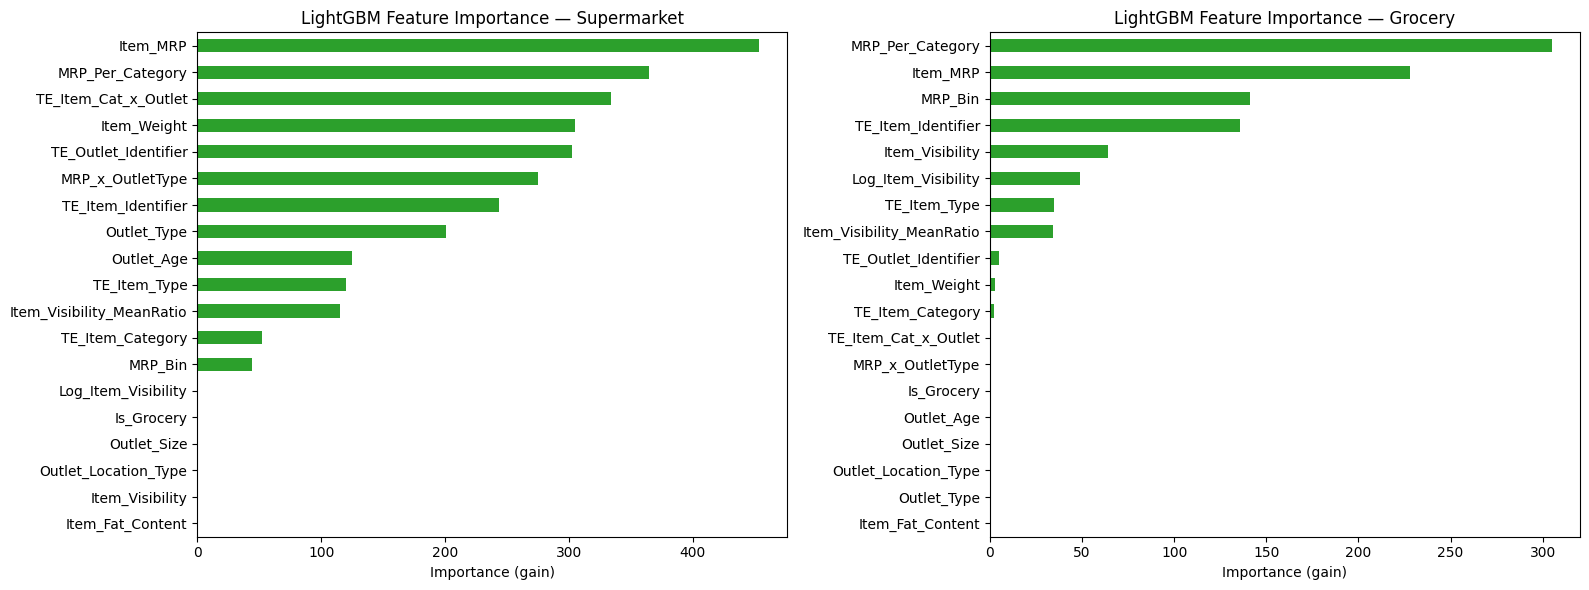

In [13]:
def get_importance(model, features):
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=features)
    return None

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (trainer, name) in zip(axes, [(trainer_sup,'Supermarket'),(trainer_groc,'Grocery')]):
    imp = get_importance(trainer.model_, FEATURES)
    if imp is not None:
        imp.sort_values().tail(20).plot(kind='barh', ax=ax, color='#2ca02c')
        ax.set_title(f'LightGBM Feature Importance — {name}')
        ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()


## 14 · Permutation Importance

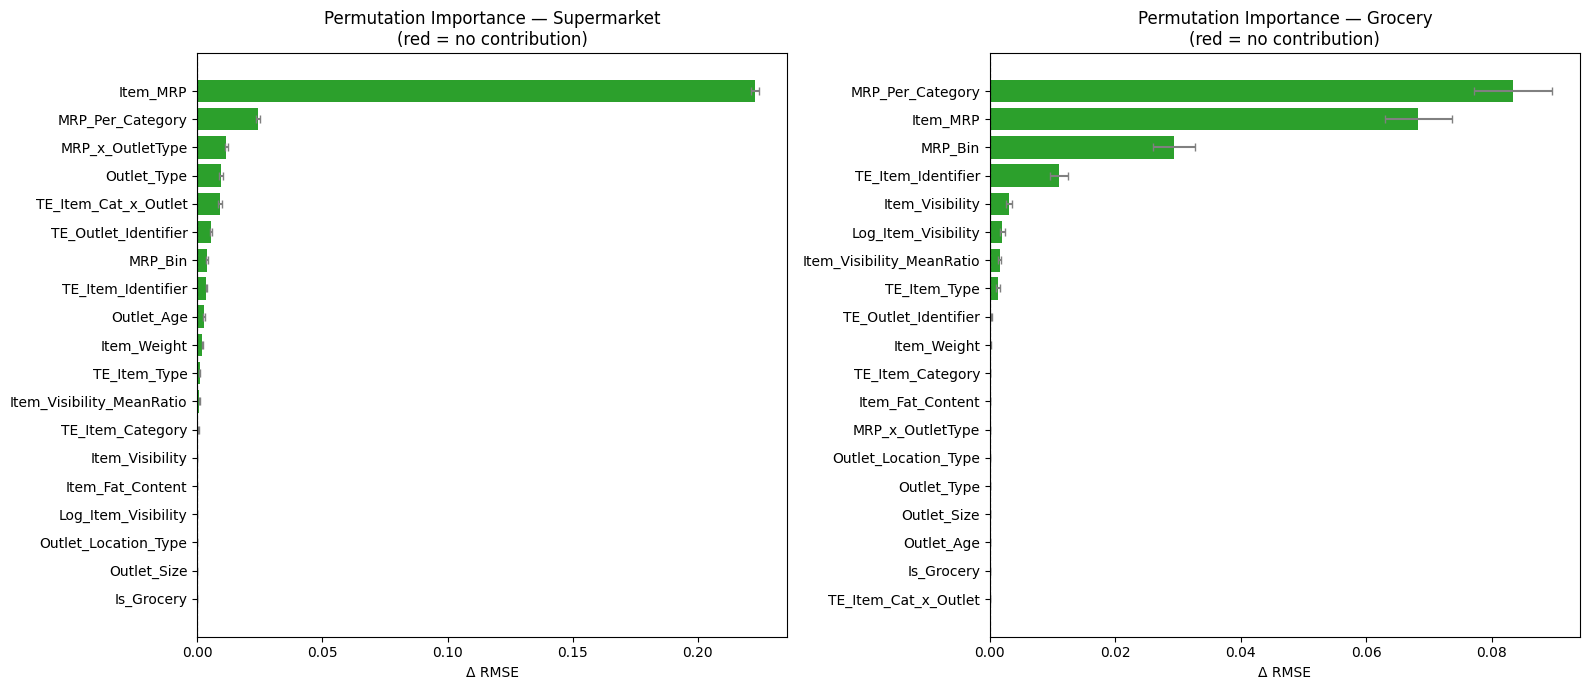

Consensus drop (both splits): {'Is_Grocery', 'Outlet_Size', 'Item_Fat_Content', 'Outlet_Location_Type'}


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
perm_results = {}

for ax, (trainer, X_cv, y_cv, name) in zip(axes, [
    (trainer_sup,  X_sup,  y_sup,  'Supermarket'),
    (trainer_groc, X_groc, y_groc, 'Grocery'),
]):
    result = permutation_importance(
        trainer.model_, X_cv, y_cv,
        n_repeats=20, random_state=SEED,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    imp_df = pd.DataFrame({
        'feature': FEATURES,
        'mean'   : result.importances_mean,
        'std'    : result.importances_std,
    }).sort_values('mean', ascending=False)
    perm_results[name] = imp_df

    colors = ['salmon' if v <= 0 else '#2ca02c' for v in imp_df['mean']]
    ax.barh(imp_df['feature'], imp_df['mean'], xerr=imp_df['std'],
            color=colors, ecolor='gray', capsize=3)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'Permutation Importance — {name}\n(red = no contribution)')
    ax.set_xlabel('Δ RMSE')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Consensus drop
drop_sup  = set(perm_results['Supermarket'][perm_results['Supermarket']['mean']<=0]['feature'])
drop_groc = set(perm_results['Grocery'][perm_results['Grocery']['mean']<=0]['feature'])
print('Consensus drop (both splits):', drop_sup & drop_groc or 'None')


## 15 · Prediction Diagnostics

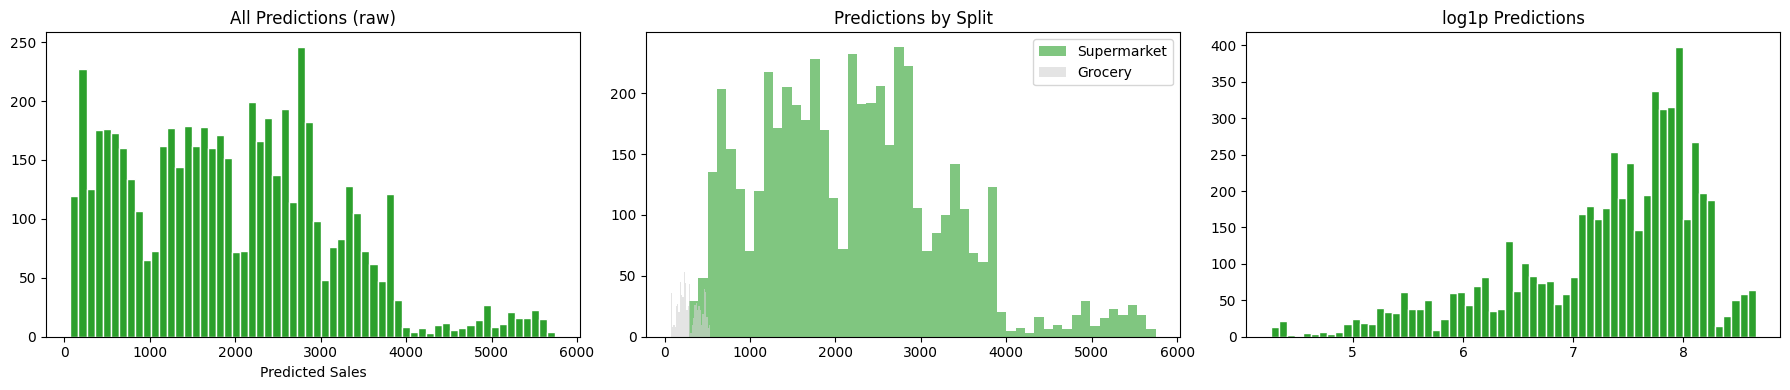

Supermarket mean: 2189.21  std: 1086.74
Grocery     mean: 291.52  std: 124.31
Negative preds  : 0


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(final_preds, bins=60, color='#2ca02c', edgecolor='white')
axes[0].set_title('All Predictions (raw)')
axes[0].set_xlabel('Predicted Sales')

axes[1].hist(preds_sup,  bins=50, alpha=0.6, color='#2ca02c',   label='Supermarket')
axes[1].hist(preds_groc, bins=30, alpha=0.6, color='lightgray', label='Grocery')
axes[1].set_title('Predictions by Split')
axes[1].legend()

axes[2].hist(np.log1p(final_preds), bins=60, color='#2ca02c', edgecolor='white')
axes[2].set_title('log1p Predictions')
plt.tight_layout()
plt.show()

print(f'Supermarket mean: {preds_sup.mean():.2f}  std: {preds_sup.std():.2f}')
print(f'Grocery     mean: {preds_groc.mean():.2f}  std: {preds_groc.std():.2f}')
print(f'Negative preds  : {(final_preds < 0).sum()}')


## Summary

In [16]:
print('=' * 60)
print('LIGHTGBM STANDALONE — RESULTS SUMMARY')
print('=' * 60)
print(f'  Supermarket OOF RMSE : {cv_sup["oof_rmse"]:,.2f}  (n={n_sup})')
print(f'  Grocery     OOF RMSE : {cv_groc["oof_rmse"]:,.2f}  (n={n_groc})')
print(f'  Combined    OOF RMSE : {combined_rmse:,.2f}')
print(f'  Submission           : {OUT_PATH}')
print()
print('  Best hyperparams (Supermarket):')
for k, v in params_sup.items():
    if k not in ('tree_method','random_state','n_jobs','verbosity',
                 'random_seed','verbose','allow_writing_files'):
        print(f'    {k:25s}: {v}')
print('=' * 60)


LIGHTGBM STANDALONE — RESULTS SUMMARY
  Supermarket OOF RMSE : 1,185.47  (n=7440)
  Grocery     OOF RMSE : 219.46  (n=1083)
  Combined    OOF RMSE : 1,062.72
  Submission           : outputs/submission_bigmart_lgb.csv

  Best hyperparams (Supermarket):
    n_estimators             : 1619
    max_depth                : 3
    learning_rate            : 0.013038032424088415
    num_leaves               : 300
    subsample                : 0.9639378281338409
    colsample_bytree         : 0.9747304090767727
    min_child_samples        : 35
    reg_alpha                : 1.54118149899264e-08
    reg_lambda               : 2.9983891992079596e-06
    min_split_gain           : 0.5159334470293081
